In [48]:
# general
import numpy as np
import math
import matplotlib.pyplot as plt

# qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import GroverOperator, MCMT, ZGate
from qiskit.visualization import plot_histogram

# qiskit runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

# simulation
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2

Let's see how important is the $\theta$ and the value of $t$

Scatter plot


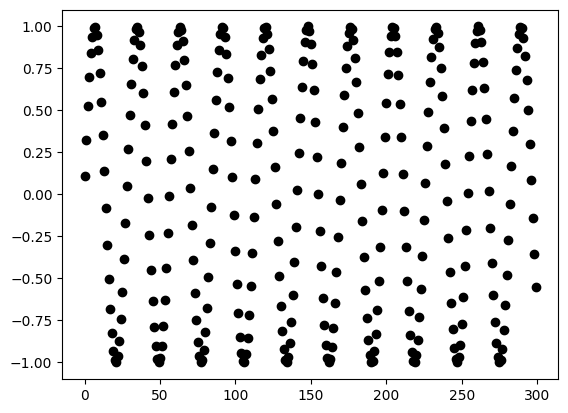

Linear interpolation


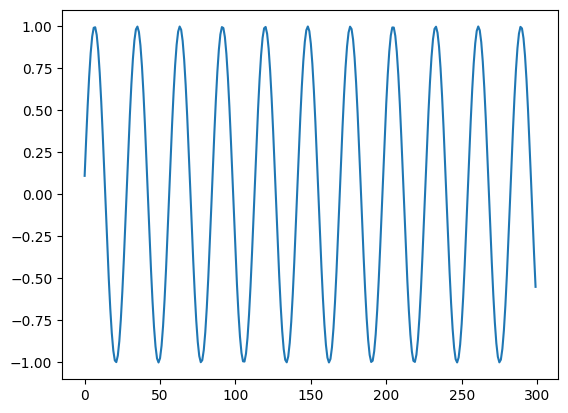

In [12]:
# define the angle
theta = 1 / 9  # angle in radians (can be changed as desired)
# define the iterations
t = np.arange(0, 300, 1)  # (start, stop, step)
# square of the probability
y = np.sin((2 * t + 1) * theta)

print("Scatter plot")
plt.plot(t, y, "o", color="black")
plt.show()

print("Linear interpolation")
plt.plot(t, y)
plt.show()

The impact of the number of strings $n$ is that if we increase it, the probability increase too

In [13]:
for n in range(1, 20):
    N = 2**n
    theta = np.arcsin(np.sqrt(1 / N))
    t = math.floor(np.pi / (4 * theta))
    p = np.sin((2 * t + 1) * theta) ** 2
    print("%d\t %12.10f" % (N, p))

2	 0.5000000000
4	 1.0000000000
8	 0.9453125000
16	 0.9613189697
32	 0.9991823155
64	 0.9965856808
128	 0.9956198657
256	 0.9999470421
512	 0.9994480262
1024	 0.9994612447
2048	 0.9999968478
4096	 0.9999453461
8192	 0.9999157752
16384	 0.9999997811
32768	 0.9999868295
65536	 0.9999882596
131072	 0.9999992587
262144	 0.9999978382
524288	 0.9999997279


See also, we need to take intro account the number of solutions, because if not, the probability decrease it

In [14]:
# Starting the loop with n=2 because we can't have 4 solutions
# when n=1.

for n in range(2, 20):
    N = 2**n
    wrong_theta = np.arcsin(np.sqrt(1 / N))
    correct_theta = np.arcsin(np.sqrt(4 / N))
    t = math.floor(np.pi / (4 * wrong_theta))
    p = np.sin((2 * t + 1) * correct_theta) ** 2
    print("%d\t %12.10f" % (N, p))

4	 1.0000000000
8	 0.5000000000
16	 0.2500000000
32	 0.0122070313
64	 0.0203807689
128	 0.0144530758
256	 0.0000705058
512	 0.0019310741
1024	 0.0023009083
2048	 0.0000077506
4096	 0.0002301502
8192	 0.0003439882
16384	 0.0000007053
32768	 0.0000533810
65536	 0.0000472907
131072	 0.0000030066
262144	 0.0000086824
524288	 0.0000010820


In [15]:
s = 7  # Number of solutions. This can be any positive integer.

# The loop starts with the smallest value of n that allows s solutions.
for n in range(math.ceil(math.log2(s)), math.ceil(math.log2(s)) + 20):
    N = 2**n
    theta = np.arcsin(np.sqrt(s / N))
    t = math.floor(np.pi / (4 * theta))
    p = np.sin((2 * t + 1) * theta) ** 2
    print("%d\t %12.10f" % (N, np.sin((2 * t + 1) * theta) ** 2))

8	 0.8750000000
16	 0.6835937500
32	 0.9877929688
64	 0.9869401455
128	 0.9933758959
256	 0.9942813445
512	 0.9977678832
1024	 0.9999963373
2048	 0.9999257666
4096	 0.9983374778
8192	 0.9995465664
16384	 0.9995822234
32768	 0.9999531497
65536	 0.9998961946
131072	 0.9999998224
262144	 0.9999745784
524288	 0.9999894829
1048576	 0.9999939313
2097152	 0.9999979874
4194304	 0.9999986243


## Grover's algorithm

In [50]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])

    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bit-string
        zero_inds = [ind for ind in range(num_qubits) if rev_target.startswith("0", ind)]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bit-string has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    return qc

C:\Users\isaac\AppData\Local\Temp\ipykernel_3496\2149212773.py:27: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)


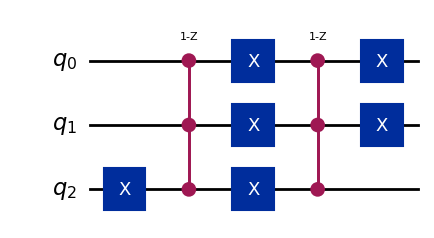

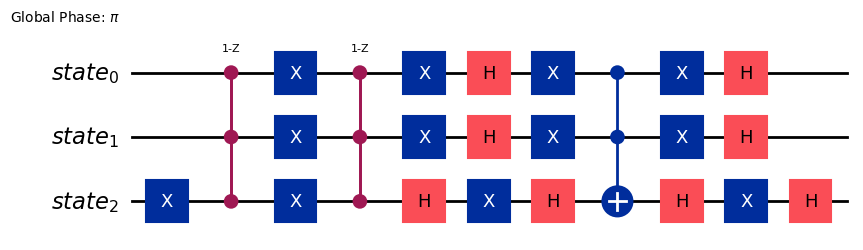

In [51]:
# plot the oracle for a marked state
marked_states = ["011", "100"]

oracle = grover_oracle(marked_states)
display(oracle.draw(output="mpl", style="iqp"))

# define the Grover operator from the oracle
grover_op = GroverOperator(oracle)
display(grover_op.decompose().draw(output="mpl", style="iqp"))

C:\Users\isaac\AppData\Local\Temp\ipykernel_3496\2149212773.py:27: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)


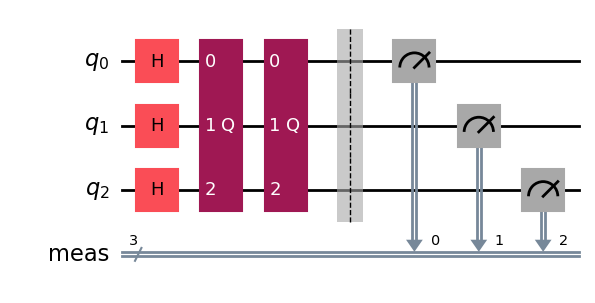

In [52]:
# marked states
marked_states = ['011']

# define the optimal number of iterations
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

# oracle
oracle = grover_oracle(marked_states)

# Grover operator
grover_op = GroverOperator(oracle)

# full quantum circuit
n_qubits = grover_op.num_qubits

qc = QuantumCircuit(n_qubits)

# apply the Hadamard gates to |0^n>
qc.h(range(n_qubits))

# apply the G operator
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)

# measure all qubits
qc.measure_all()

# draw
display(qc.draw(output='mpl'))

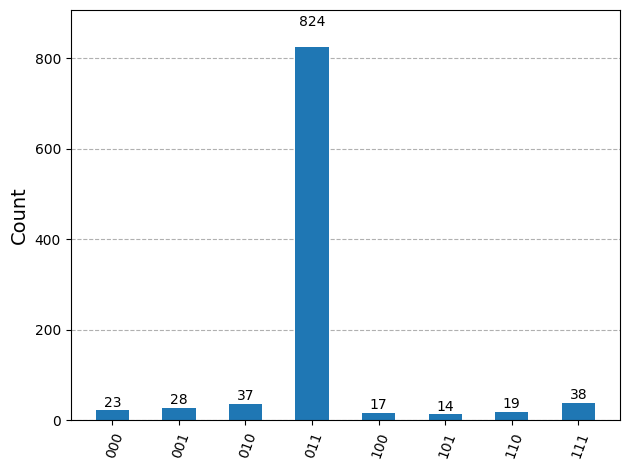

Marked states: ['011']


In [62]:
# execute the simulation on a fake real device
fake_backend = GenericBackendV2(n_qubits)
simulator    = AerSimulator.from_backend(fake_backend)

# compiled circuit
compiled_circuit = transpile(qc, simulator)

# run
results = simulator.run(compiled_circuit, shots=1000).result()
stats   = results.get_counts()

# plot results
display(plot_histogram(stats))
print(f'Marked states: {marked_states}')